# B16 — Kiểm tra chất lượng dữ liệu

Bước B16 kiểm tra bảng `reviews_clean.parquet` trước khi sử dụng cho các phân tích SLA và mô hình hóa. Nội dung tập trung vào quy mô dữ liệu, các cờ chất lượng, các biến thời gian, data contract và tính nhất quán của trọng số.

Các phép kiểm được thực hiện trực tiếp trên dữ liệu sau bước làm sạch. Notebook không xây dựng lại quá trình làm sạch dữ liệu.

## 1. Đọc dữ liệu và mô tả tổng quan

Bảng `reviews_clean.parquet` là dữ liệu đầu vào cho các bước phân tích tiếp theo. Trước hết cần xác định số lượng review, sản phẩm, nhà bán, ngành hàng và số dòng đáp ứng điều kiện phân tích.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

while ROOT != ROOT.parent and not (ROOT / "src").exists():
    ROOT = ROOT.parent

if not (ROOT / "src").exists():
    raise FileNotFoundError(
        "Không tìm thấy thư mục src/. Hãy mở notebook trong thư mục gốc của project."
    )

sys.path.insert(0, str(ROOT))

CLEAN_PATH = ROOT / "data" / "processed" / "reviews_clean.parquet"

if not CLEAN_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy dữ liệu: {CLEAN_PATH}")

df = pd.read_parquet(CLEAN_PATH)

required_cols = {
    "review_id",
    "product_id",
    "seller_id",
    "rating",
    "quality_flag",
    "is_analysable",
    "weight",
}
missing_cols = required_cols - set(df.columns)

if missing_cols:
    raise ValueError(f"Thiếu các cột bắt buộc: {sorted(missing_cols)}")

summary = pd.DataFrame({
    "Chỉ tiêu": [
        "Số review",
        "Số cột",
        "Số sản phẩm",
        "Số nhà bán",
        "Số ngành hàng",
        "Số dòng phân tích được",
        "Tỷ lệ phân tích được",
        "Tổng trọng số"
    ],
    "Giá trị": [
        len(df),
        len(df.columns),
        df["product_id"].nunique(),
        df["seller_id"].nunique(),
        df["category_name"].nunique() if "category_name" in df.columns else np.nan,
        int(df["is_analysable"].sum()),
        f"{df['is_analysable'].mean() * 100:.2f}%",
        f"{pd.to_numeric(df['weight'], errors='coerce').sum():,.2f}",
    ]
})

display(summary)

,Chỉ tiêu,Giá trị
0,Số review,203510
1,Số cột,43
2,Số sản phẩm,2438
3,Số nhà bán,366
4,Số ngành hàng,10
5,Số dòng phân tích được,198355
6,Tỷ lệ phân tích được,97.47%
7,Tổng trọng số,"438,255.30"


## 2. Cấu trúc dữ liệu và dữ liệu thiếu

Kiểm tra kiểu dữ liệu và số lượng giá trị thiếu của các biến giúp xác định những trường có thể ảnh hưởng đến việc tính thời gian giao hàng và các biến liên quan đến SLA.

In [2]:
schema = pd.DataFrame({
    "Biến": df.columns,
    "Kiểu dữ liệu": [str(df[c].dtype) for c in df.columns],
    "Thiếu (n)": [int(df[c].isna().sum()) for c in df.columns],
    "Thiếu (%)": [round(df[c].isna().mean() * 100, 2) for c in df.columns],
})

schema = schema.sort_values(
    ["Thiếu (n)", "Biến"],
    ascending=[False, True]
).reset_index(drop=True)

display(schema)

,Biến,Kiểu dữ liệu,Thiếu (n),Thiếu (%)
0,customer_says_late,object,187477,92.12
1,dr_dong_goi,object,187477,92.12
2,dr_gio_giao,object,187477,92.12
3,dr_shipper,object,187477,92.12
4,dr_thoi_gian,object,187477,92.12
5,customer_joined,object,21167,10.40
6,gap_days,float64,5155,2.53
7,sla_breach,object,5155,2.53
8,sla_status,object,5155,2.53
9,lead_days,float64,3344,1.64


## 3. Phân bố `quality_flag`

`quality_flag` ghi nhận trạng thái chất lượng của từng review. Các giá trị này được tạo trong quá trình làm sạch dữ liệu và cho biết nguyên nhân một dòng có thể không được sử dụng cho phân tích SLA.

In [3]:
flag_order = [
    "ok",
    "thiếu delivery_date",
    "lead_days âm",
    "thiếu purchased_at",
    "lead_days > 90 ngày",
]

quality = (
    df["quality_flag"]
    .value_counts(dropna=False)
    .rename_axis("quality_flag")
    .reset_index(name="n")
)

quality["Tỷ lệ (%)"] = (quality["n"] / len(df) * 100).round(2)

analysable_by_flag = (
    df.groupby("quality_flag", dropna=False)["is_analysable"]
    .sum()
)

quality["Phân tích được (n)"] = (
    quality["quality_flag"]
    .map(analysable_by_flag)
    .fillna(0)
    .astype(int)
)

order_map = {name: i for i, name in enumerate(flag_order)}
quality["_order"] = quality["quality_flag"].astype(str).map(order_map).fillna(len(flag_order))
quality = (
    quality
    .sort_values(["_order", "quality_flag"])
    .drop(columns="_order")
    .reset_index(drop=True)
)

display(quality)

,quality_flag,n,Tỷ lệ (%),Phân tích được (n)
0,ok,198355,97.47,198355
1,thiếu delivery_date,3064,1.51,0
2,lead_days âm,1799,0.88,0
3,thiếu purchased_at,280,0.14,0
4,lead_days > 90 ngày,12,0.01,0


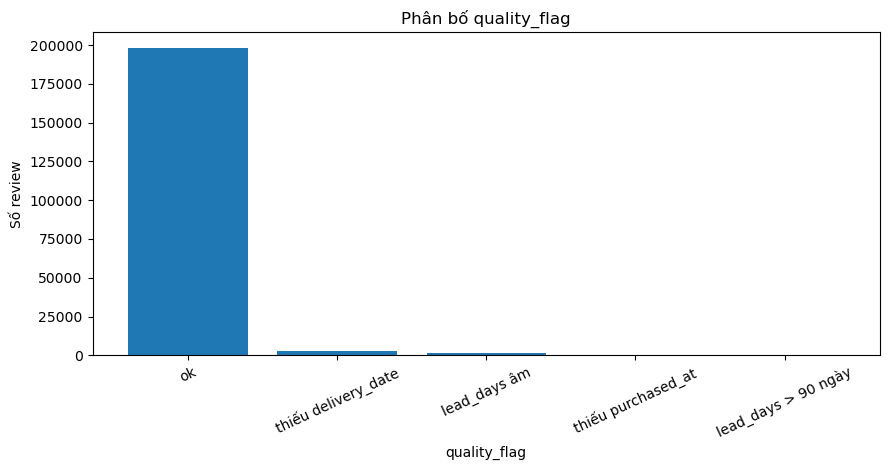

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(quality["quality_flag"].astype(str), quality["n"])
ax.set_title("Phân bố quality_flag")
ax.set_xlabel("quality_flag")
ax.set_ylabel("Số review")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
plt.show()

### Dữ liệu được sử dụng cho phân tích

`is_analysable` được sử dụng để phân biệt tổng số review trong bảng với số review đáp ứng điều kiện của pipeline.

In [5]:
analysable_table = pd.DataFrame({
    "Trạng thái": ["Phân tích được", "Không phân tích được"],
    "Số review": [
        int(df["is_analysable"].sum()),
        int((~df["is_analysable"]).sum()),
    ],
})

analysable_table["Tỷ lệ (%)"] = (
    analysable_table["Số review"] / len(df) * 100
).round(2)

display(analysable_table)

,Trạng thái,Số review,Tỷ lệ (%)
0,Phân tích được,198355,97.47
1,Không phân tích được,5155,2.53


## 4. Kiểm tra các biến thời gian

Các biến thời gian là cơ sở để tính `lead_days` và `gap_days`. Vì vậy, cần kiểm tra mức độ đầy đủ của các trường thời gian trước khi sử dụng chúng trong phân tích SLA.

In [6]:
time_cols = [
    c for c in [
        "purchased_at",
        "delivery_date",
        "review_created_date",
        "purchased_ts",
        "delivered_ts",
        "review_ts",
        "lead_days",
        "gap_days",
    ]
    if c in df.columns
]

time_quality = pd.DataFrame({
    "Biến": time_cols,
    "Thiếu (n)": [int(df[c].isna().sum()) for c in time_cols],
    "Thiếu (%)": [round(df[c].isna().mean() * 100, 2) for c in time_cols],
})

display(time_quality)

if "lead_days" in df.columns:
    lead_days = pd.to_numeric(df["lead_days"], errors="coerce")
    display(
        lead_days.describe()
        .rename("lead_days")
        .to_frame()
        .round(2)
    )

,Biến,Thiếu (n),Thiếu (%)
0,purchased_at,280,0.14
1,delivery_date,3220,1.58
2,review_created_date,3220,1.58
3,purchased_ts,280,0.14
4,delivered_ts,3220,1.58
5,review_ts,3220,1.58
6,lead_days,3344,1.64
7,gap_days,5155,2.53


,lead_days
count,200166.00
mean,0.97
std,24.96
min,-1586.11
25%,0.64
50%,1.43
75%,2.82
max,270.64


## 5. Kiểm tra data contract

Data contract của project xác định các điều kiện mà bảng dữ liệu sau khi làm sạch phải đáp ứng. Notebook gọi trực tiếp `validate_clean_reviews()` để kiểm tra toàn bộ các điều kiện này.

In [7]:
from dataclasses import is_dataclass, asdict
from src.validate.contract import validate_clean_reviews
from src.clean.reviews import SLA_MAX_DAYS

contract_report = validate_clean_reviews(
    df,
    sla_days=SLA_MAX_DAYS
)

def extract_checks(report):
    for attr in ("checks", "results", "items"):
        value = getattr(report, attr, None)
        if value is not None:
            return list(value)
    return []

def normalise_check(item):
    if is_dataclass(item):
        data = asdict(item)
    elif isinstance(item, dict):
        data = dict(item)
    else:
        data = {
            "name": getattr(item, "name", getattr(item, "label", "")),
            "passed": getattr(item, "passed", getattr(item, "ok", None)),
            "detail": getattr(item, "detail", getattr(item, "message", "")),
        }

    return {
        "Tên kiểm tra": str(data.get("name", data.get("label", ""))),
        "Kết quả": data.get(
            "passed",
            data.get("ok", data.get("success", None))
        ),
        "Chi tiết": str(
            data.get(
                "detail",
                data.get("message", data.get("reason", ""))
            )
        ),
    }

checks = pd.DataFrame(
    [normalise_check(x) for x in extract_checks(contract_report)]
)

if checks.empty:
    raise RuntimeError(
        "Không lấy được danh sách các phép kiểm từ ContractReport."
    )

checks["Kết quả"] = checks["Kết quả"].map({
    True: "PASS",
    False: "FAIL"
}).fillna("UNKNOWN")

checks.insert(0, "STT", range(1, len(checks) + 1))

display(checks)

n_checks = len(checks)
n_pass = int((checks["Kết quả"] == "PASS").sum())
n_fail = int((checks["Kết quả"] == "FAIL").sum())

print(f"Tổng số phép kiểm: {n_checks}")
print(f"PASS: {n_pass}")
print(f"FAIL: {n_fail}")

assert n_checks == 22, f"Data contract trả về {n_checks} phép kiểm, không phải 22."
assert n_pass == 22, "Data contract chưa đạt 22/22 PASS."

,STT,Tên kiểm tra,Kết quả,Chi tiết
0,1,đủ cột bắt buộc,PASS,
1,2,bảng không rỗng,PASS,n=203510
2,3,bản sao review_id phải trùng khớp nội dung,PASS,"0 bản sao, 0 bản sao mâu thuẫn"
3,4,rating ∈ {1..5},PASS,0 dòng ngoài khoảng
4,5,độ phủ purchased_at ≥ 95%,PASS,thực tế 99.9%
5,6,độ phủ delivery_date ≥ 90%,PASS,thực tế 98.4%
6,7,độ phủ review_created_date ≥ 90%,PASS,thực tế 98.4%
7,8,độ phủ nhãn giao hàng ≥ 5%,PASS,thực tế 7.9%
8,9,stratum khớp rating,PASS,0 dòng lệch
9,10,số lấy mẫu ≤ kích thước tầng,PASS,0 dòng vi phạm


Tổng số phép kiểm: 22
PASS: 22
FAIL: 0


Kết quả `22/22 PASS` cho biết bảng `reviews_clean` đáp ứng toàn bộ các điều kiện được định nghĩa trong data contract của project tại thời điểm kiểm tra. Kết quả này phản ánh việc dữ liệu đạt các quy tắc đã đặt ra, không có nghĩa dữ liệu không còn bất kỳ hạn chế nào.

## 6. Kiểm tra tổng trọng số

`weight` được sử dụng để quy đổi dữ liệu lấy mẫu phân tầng về quy mô quần thể. Một phép kiểm tra độc lập là đối chiếu `Σ weight` của bảng review với `Σ review_count` ở cấp product.

Nguồn `review_count` được loại trùng theo `product_id` trước khi tính tổng để tránh cộng lặp cùng một sản phẩm.

In [8]:
def read_table(path):
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    return pd.read_csv(path)

candidate_paths = []

for base in [ROOT / "data" / "raw", ROOT / "data" / "processed"]:
    if base.exists():
        candidate_paths.extend(base.rglob("*.parquet"))
        candidate_paths.extend(base.rglob("*.csv"))

product_candidates = []

for path in candidate_paths:
    try:
        if path.suffix.lower() == ".parquet":
            columns = set(pd.read_parquet(path).columns)
        else:
            columns = set(pd.read_csv(path, nrows=0).columns)
    except Exception:
        continue

    if {"product_id", "review_count"}.issubset(columns):
        product_candidates.append(path)

def candidate_rank(path):
    text = str(path).lower()
    return (
        "archive" in text,
        "tiki_products" not in text,
        "raw" not in text,
        str(path),
    )

product_candidates = sorted(
    set(product_candidates),
    key=candidate_rank
)

if not product_candidates:
    raise FileNotFoundError(
        "Không tìm thấy bảng product có đủ product_id và review_count."
    )

product_path = product_candidates[0]
products = read_table(product_path)

products_unique = (
    products
    .drop_duplicates(subset=["product_id"])
    .copy()
)

products_unique["review_count"] = pd.to_numeric(
    products_unique["review_count"],
    errors="coerce"
)

products_unique = products_unique.dropna(
    subset=["review_count"]
)

sigma_weight = float(
    pd.to_numeric(df["weight"], errors="coerce").sum()
)

sigma_review_count = float(
    products_unique["review_count"].sum()
)

difference = sigma_weight - sigma_review_count

relative_difference = (
    abs(difference) / sigma_review_count * 100
    if sigma_review_count
    else np.nan
)

weight_check = pd.DataFrame({
    "Chỉ tiêu": [
        "Nguồn dữ liệu review",
        "Nguồn review_count",
        "Số product sau khi loại trùng",
        "Σ weight",
        "Σ review_count",
        "Chênh lệch (Σweight - Σreview_count)",
        "Độ lệch tương đối (%)",
    ],
    "Giá trị": [
        str(CLEAN_PATH.relative_to(ROOT)),
        str(product_path.relative_to(ROOT)),
        f"{len(products_unique):,}",
        f"{sigma_weight:,.2f}",
        f"{sigma_review_count:,.2f}",
        f"{difference:,.2f}",
        f"{relative_difference:.4f}%",
    ]
})

display(weight_check)

,Chỉ tiêu,Giá trị
0,Nguồn dữ liệu review,data/processed/reviews_clean.parquet
1,Nguồn review_count,data/raw/tiki_products.parquet
2,Số product sau khi loại trùng,"2,438"
3,Σ weight,"438,255.30"
4,Σ review_count,"438,295.00"
5,Chênh lệch (Σweight - Σreview_count),-39.70
6,Độ lệch tương đối (%),0.0091%


Hai tổng trên được dùng như một phép kiểm tra tính nhất quán của quy mô quần thể giữa bảng review và bảng product. Chênh lệch quan sát được được giữ nguyên trong kết quả, không điều chỉnh thủ công trọng số để làm hai tổng bằng nhau.

## 7. Kết luận

B16 xác định tình trạng chất lượng của `reviews_clean` thông qua ba nhóm kiểm tra: phân loại chất lượng từng dòng, kiểm tra data contract và đối chiếu trọng số với quy mô review ở cấp product. Kết quả của các bảng trên được sử dụng để xác định tập dữ liệu hợp lệ cho các phân tích tiếp theo.

In [9]:
ok_n = int((df["quality_flag"] == "ok").sum())
analysable_n = int(df["is_analysable"].sum())

conclusion = pd.DataFrame({
    "Nội dung": [
        "Tổng số review",
        "Review có quality_flag = ok",
        "Review có thể phân tích",
        "Data contract",
        "Σ weight",
        "Σ review_count",
        "Chênh lệch tuyệt đối"
    ],
    "Kết quả": [
        f"{len(df):,}",
        f"{ok_n:,} ({ok_n / len(df) * 100:.2f}%)",
        f"{analysable_n:,} ({analysable_n / len(df) * 100:.2f}%)",
        f"{n_pass}/{n_checks} PASS",
        f"{sigma_weight:,.2f}",
        f"{sigma_review_count:,.2f}",
        f"{difference:,.2f}"
    ]
})

display(conclusion)

,Nội dung,Kết quả
0,Tổng số review,"203,510"
1,Review có quality_flag = ok,"198,355 (97.47%)"
2,Review có thể phân tích,"198,355 (97.47%)"
3,Data contract,22/22 PASS
4,Σ weight,"438,255.30"
5,Σ review_count,"438,295.00"
6,Chênh lệch tuyệt đối,-39.70
